<a href="https://colab.research.google.com/github/GH-Rumi/PemMes_7_Helmi/blob/main/JS04/JS04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Regresi - Lab 0**

# **1. Random Split**

In [1]:
import pandas as pd

df = pd.read_csv('Titanic-Dataset-selected.csv')
df.head()

,Survived,Pclass,Age,Sex,Cabin
0,0,3,-0.592481,1,115
1,1,1,0.638789,0,81
2,1,3,-0.284663,0,115
3,1,1,0.407926,0,55
4,0,3,0.407926,1,115


In [2]:
# Split data
from sklearn.model_selection import train_test_split

# Split data training dan dan lainnya
# data lainnya, akan kita split lagi menjadi validasi dan testing.
# Rasio yang akan kita gunakan adalah 8:1:1
df_train, df_unseen = train_test_split(df, test_size=0.2, random_state=0)

# Split lagi antara validasi dan testing
df_val, df_test = train_test_split(df_unseen, test_size=0.5, random_state=0)

# Cek masing-masing ukuran data

print(f'Jumlah data asli: {df.shape[0]}')
print(f'Jumlah data train: {df_train.shape[0]}')
print(f'Jumlah data val: {df_val.shape[0]}')
print(f'Jumlah data test: {df_test.shape[0]}')

# Cek rasio tiap label
print('=========')
print(f'Jumlah label data asli:\n{df.Survived.value_counts()}')
print(f'Jumlah label data train:\n{df_train.Survived.value_counts()}')
print(f'Jumlah label data val:\n{df_val.Survived.value_counts()}')
print(f'Jumlah label data test:\n{df_test.Survived.value_counts()}')

Jumlah data asli: 891
Jumlah data train: 712
Jumlah data val: 89
Jumlah data test: 90
Jumlah label data asli:
Survived
0    549
1    342
Name: count, dtype: int64
Jumlah label data train:
Survived
0    439
1    273
Name: count, dtype: int64
Jumlah label data val:
Survived
0    53
1    36
Name: count, dtype: int64
Jumlah label data test:
Survived
0    57
1    33
Name: count, dtype: int64


# **2. Stratified Split**

In [3]:
import pandas as pd

df2 = pd.read_csv('Titanic-Dataset-selected.csv')
df2.head()

,Survived,Pclass,Age,Sex,Cabin
0,0,3,-0.592481,1,115
1,1,1,0.638789,0,81
2,1,3,-0.284663,0,115
3,1,1,0.407926,0,55
4,0,3,0.407926,1,115


In [4]:
# Split data
from sklearn.model_selection import train_test_split

# Split data training dan dan lainnya
# data lainnya, akan kita split lagi menjadi validasi dan testing.
# Rasio yang akan kita gunakan adalah 8:1:1
df2_train, df2_unseen = train_test_split(df2, test_size=0.2, random_state=0, stratify=df['Survived'])

# Split lagi antara validasi dan testing
df2_val, df2_test = train_test_split(df2_unseen, test_size=0.5, random_state=0, stratify=df_unseen['Survived'])

# Cek masing-masing ukuran data

print(f'Jumlah label data asli:\n{df2.Survived.value_counts()}')
print(f'Jumlah label data train:\n{df2_train.Survived.value_counts()}')
print(f'Jumlah label data val:\n{df2_val.Survived.value_counts()}')
print(f'Jumlah label data test:\n{df2_test.Survived.value_counts()}')

Jumlah label data asli:
Survived
0    549
1    342
Name: count, dtype: int64
Jumlah label data train:
Survived
0    439
1    273
Name: count, dtype: int64
Jumlah label data val:
Survived
0    51
1    38
Name: count, dtype: int64
Jumlah label data test:
Survived
0    59
1    31
Name: count, dtype: int64


# **3. Cross Validation 1**

In [6]:
import pandas as pd

df3 = pd.read_csv('Titanic-Dataset-selected.csv')
df3.head()

,Survived,Pclass,Age,Sex,Cabin
0,0,3,-0.592481,1,115
1,1,1,0.638789,0,81
2,1,3,-0.284663,0,115
3,1,1,0.407926,0,55
4,0,3,0.407926,1,115


In [7]:
# Implementasi k-fold cross validation (random) dengan training dan testing saja
from sklearn.model_selection import KFold

# inisiasi obyek kfold
kf = KFold(n_splits=4)
print(f'Jumlah fold: {kf.get_n_splits()}')
print(f'Obyek KFold: {kf}')

# Lakukan splitting dengan KFold
kf_split = kf.split(df3)
print(f'Jumlah data df: {df.shape[0]}')

# cek index data tiap fold
for train_index, test_index in kf_split:
    print(f'Index train: {train_index} | Index test: {test_index}')

Jumlah fold: 4
Obyek KFold: KFold(n_splits=4, random_state=None, shuffle=False)
Jumlah data df: 891
Index train: [223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240
 241 242 243 244 245 246 247 248 249 250 251 252 253 254 255 256 257 258
 259 260 261 262 263 264 265 266 267 268 269 270 271 272 273 274 275 276
 277 278 279 280 281 282 283 284 285 286 287 288 289 290 291 292 293 294
 295 296 297 298 299 300 301 302 303 304 305 306 307 308 309 310 311 312
 313 314 315 316 317 318 319 320 321 322 323 324 325 326 327 328 329 330
 331 332 333 334 335 336 337 338 339 340 341 342 343 344 345 346 347 348
 349 350 351 352 353 354 355 356 357 358 359 360 361 362 363 364 365 366
 367 368 369 370 371 372 373 374 375 376 377 378 379 380 381 382 383 384
 385 386 387 388 389 390 391 392 393 394 395 396 397 398 399 400 401 402
 403 404 405 406 407 408 409 410 411 412 413 414 415 416 417 418 419 420
 421 422 423 424 425 426 427 428 429 430 431 432 433 434 435 436 437 438
 439 440 44

# **4. Cross Validation 2**

In [9]:
import pandas as pd

df4 = pd.read_csv('Titanic-Dataset-selected.csv')
df4.head()

,Survived,Pclass,Age,Sex,Cabin
0,0,3,-0.592481,1,115
1,1,1,0.638789,0,81
2,1,3,-0.284663,0,115
3,1,1,0.407926,0,55
4,0,3,0.407926,1,115


In [10]:
# Implementasi k-fold cross validation (random) dengan training, validation, dan testing data
from sklearn.model_selection import train_test_split, KFold

# Split dulu antara data training dan testing dengan train_test_split
# Rasio 8:2 untuk training dan testing
df4_train, df4_test = train_test_split(df4, test_size=0.2, random_state=0)

# inisiasi obyek kfold
kf2 = KFold(n_splits=4)
print(f'Jumlah fold: {kf2.get_n_splits()}')
print(f'Obyek KFold: {kf2}')

# Lakukan splitting dengan KFold untuk data df_training
# Dengan acara ini, kita masih memiliki data testing untuk keperluan pengujian model
# namun tetap dapat melakukan evaluasi dengan menggunakan data validasi
kf2_split = kf2.split(df_train)
print(f'Jumlah data df_train: {df4_train.shape[0]}')

# cek index data tiap fold
for train_index, test_index in kf2_split:
    print(f'Index train: {train_index} | Index test: {test_index}')

Jumlah fold: 4
Obyek KFold: KFold(n_splits=4, random_state=None, shuffle=False)
Jumlah data df_train: 712
Index train: [178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195
 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213
 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231
 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249
 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265 266 267
 268 269 270 271 272 273 274 275 276 277 278 279 280 281 282 283 284 285
 286 287 288 289 290 291 292 293 294 295 296 297 298 299 300 301 302 303
 304 305 306 307 308 309 310 311 312 313 314 315 316 317 318 319 320 321
 322 323 324 325 326 327 328 329 330 331 332 333 334 335 336 337 338 339
 340 341 342 343 344 345 346 347 348 349 350 351 352 353 354 355 356 357
 358 359 360 361 362 363 364 365 366 367 368 369 370 371 372 373 374 375
 376 377 378 379 380 381 382 383 384 385 386 387 388 389 390 391 392 393
 394 

# **Regresi - Lab 1**

In [11]:
# import package
import numpy as np
import pandas as pd

# baca data dari file CSV
data = pd.read_csv('dataset.csv')

In [12]:
# melihat beberapa data awal
data.head()

# mengecek ukuran data
data.shape

# informasi tentang data
data.info()

# deskripsi data
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [13]:
# import library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


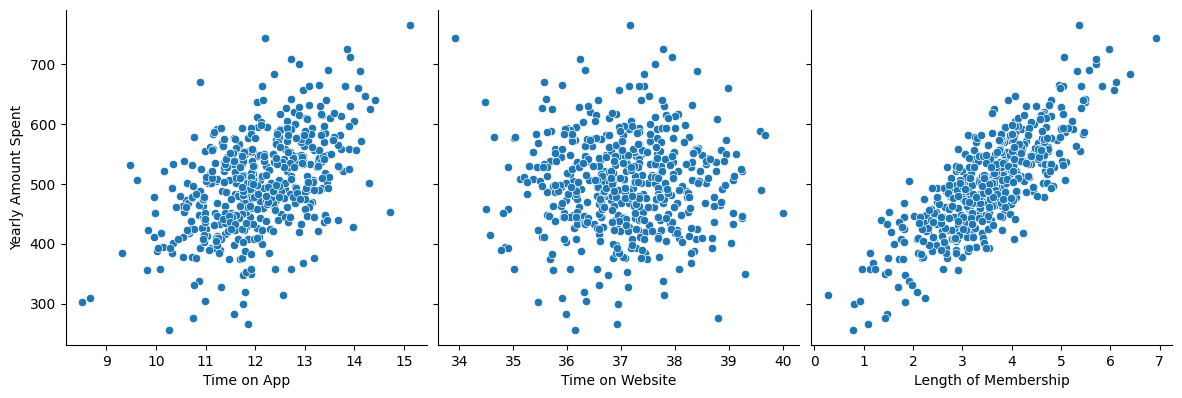

In [14]:
# visualisasi data dengan pairplot
sns.pairplot(data, x_vars=['Time on App', 'Time on Website', 'Length of Membership'],
             y_vars='Yearly Amount Spent', size=4, aspect=1, kind='scatter')
plt.show()

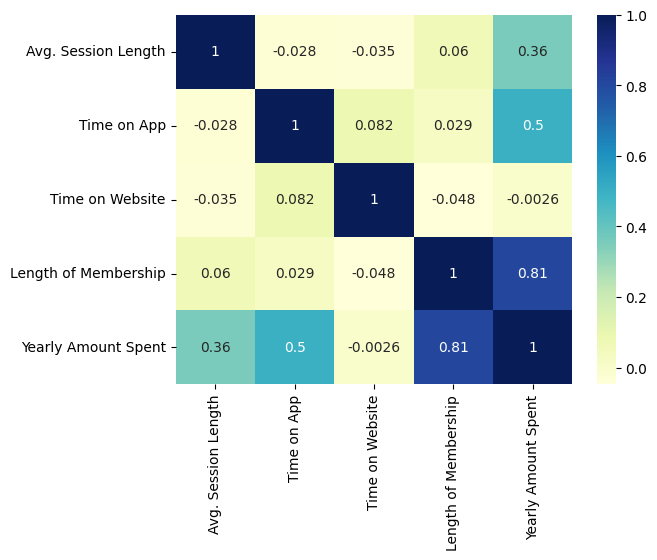

In [16]:
# visualisasi korelasi dengan heatmap
sns.heatmap(data.corr(numeric_only=True), cmap="YlGnBu", annot=True) # diubah karena error outputnya
plt.show()

In [17]:
# Membuat variabel bebas X dan Y, contoh pengambilan dari analisis korelasi sebelumnya
X = data['Length of Membership']
y = data['Yearly Amount Spent']

In [18]:
# Pembagian data latih dan data uji dengan proporsi 7:3
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=100)

In [19]:
# Training model
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)
lr = sm.OLS(y_train, X_train_sm).fit()

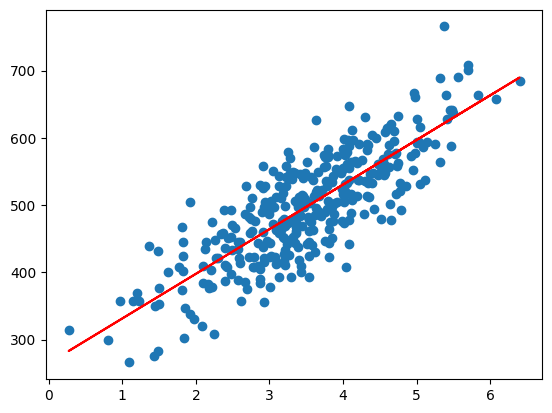

In [20]:
# Visualisasi garis regresi
plt.scatter(X_train, y_train)
plt.plot(X_train, 265.2483 + 66.3015*X_train, 'r')
plt.show()

In [21]:
# Prediksi nilai y_value dari data x yang telah dilatih
y_train_pred = lr.predict(X_train_sm)

# Menghitung residual
res = (y_train - y_train_pred)

/tmp/ipykernel_1646/594495671.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(res, bins=15)


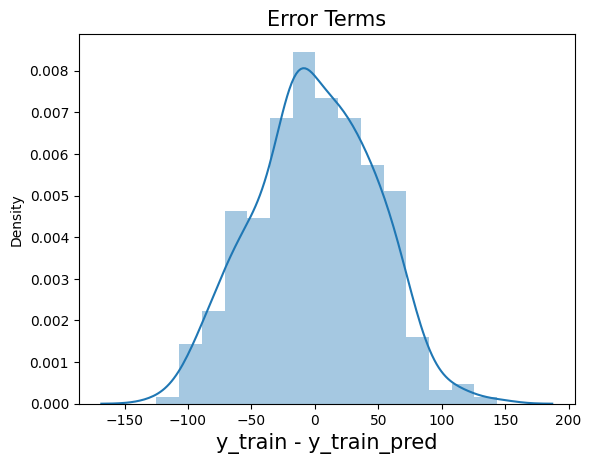

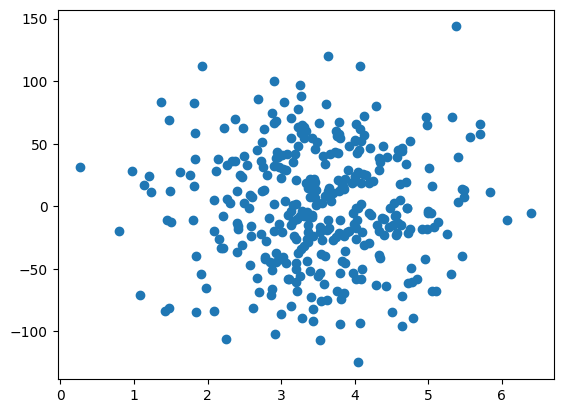

In [22]:
# Histogram residual
fig = plt.figure()
sns.distplot(res, bins=15)
plt.title('Error Terms', fontsize=15)
plt.xlabel('y_train - y_train_pred', fontsize=15)
plt.show()

# Scatter plot residual
plt.scatter(X_train, res)
plt.show()

In [23]:
# Prediksi pada data uji
X_test_sm = sm.add_constant(X_test)
y_test_pred = lr.predict(X_test_sm)

In [24]:
# Hitung nilai R-squared
from sklearn.metrics import r2_score

r_squared = r2_score(y_test, y_test_pred)

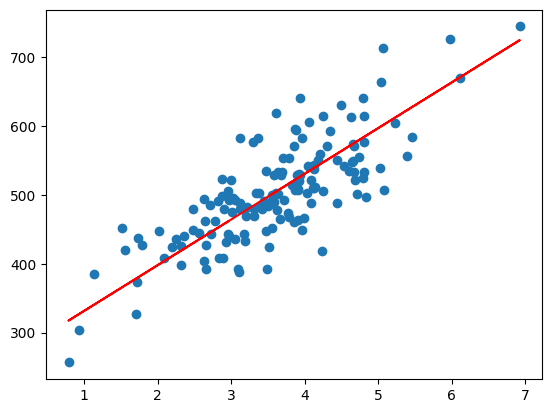

In [25]:
# Visualisasi data uji dan hasil prediksi
plt.scatter(X_test, y_test)
plt.plot(X_test, y_test_pred, 'r')
plt.show()

# **Regresi - Lab 2**

In [26]:
# Mengimpor library
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [27]:
# Mengimpor dataset (Pastikan Anda memiliki file CSV 'Posisi_gaji.csv' dalam direktori yang sama)
dataset = pd.read_csv('Posisi_gaji.csv')
X = dataset.iloc[:, 1:2].values
y = dataset.iloc[:, 2].values  # Ubah menjadi satu kolom saja

In [28]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()
X = sc_X.fit_transform(X.reshape(-1, 1))
y = sc_y.fit_transform(y.reshape(-1, 1))

In [29]:
# Fitting SVR ke dataset
from sklearn.svm import SVR
regressor = SVR(kernel='rbf')
regressor.fit(X, y)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR()

/tmp/ipykernel_1646/1841224750.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01).reshape(-1, 1)


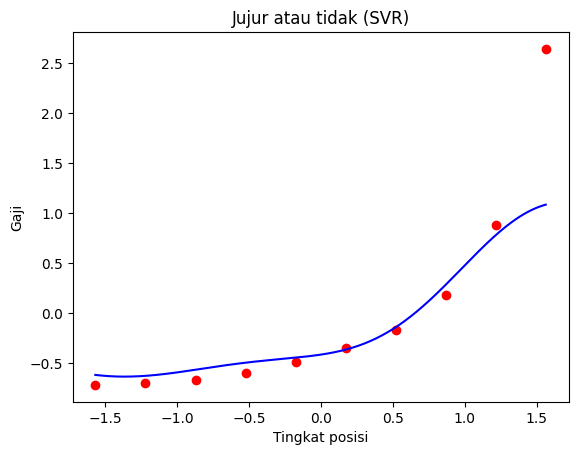

In [30]:
# Visualisasi hasil SVR (resolusi tinggi dan kurva yang lebih halus)
X_grid = np.arange(min(X), max(X), 0.01).reshape(-1, 1)
plt.scatter(X, y, color='red')
plt.plot(X_grid, regressor.predict(X_grid), color='blue')
plt.title('Jujur atau tidak (SVR)')
plt.xlabel('Tingkat posisi')
plt.ylabel('Gaji')
plt.show()

In [31]:
# Prediksi hasil
# Buat array 2D yang berisi tingkat posisi yang akan diprediksi
tingkat_posisi_prediksi = np.array([[6.5]])
# Penskalaan fitur untuk data yang akan diprediksi
tingkat_posisi_prediksi = sc_X.transform(tingkat_posisi_prediksi)
# Melakukan prediksi menggunakan model SVR
gaji_prediksi = regressor.predict(tingkat_posisi_prediksi)
# Kembalikan hasil prediksi ke skala aslinya
gaji_prediksi = sc_y.inverse_transform(gaji_prediksi.reshape(-1, 1))

In [32]:
# Menampilkan hasil prediksi
print("Prediksi Gaji untuk Tingkat Posisi 6.5:", gaji_prediksi[0])

Prediksi Gaji untuk Tingkat Posisi 6.5: [170370.0204065]


In [33]:
# Evaluasi model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_actual = y
y_pred = regressor.predict(X)

# Menghitung MAE
mae = mean_absolute_error(y_actual, y_pred)

# Menghitung MSE
mse = mean_squared_error(y_actual, y_pred)

# Menghitung RMSE
rmse = np.sqrt(mse)

# Menghitung R-squared
r2 = r2_score(y_actual, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)

MAE: 0.22299274095734414
MSE: 0.24839989293792014
RMSE: 0.4983973243687411
R-squared: 0.7516001070620798


# **Tugas Praktikum**

In [34]:
df = pd.read_csv('insurance.csv')

# **1. Identifikasi Variabel Bebas (Fitur) dan Variabel Target**

In [35]:
# Mengubah variabel kategorikal menjadi numerik (One-Hot Encoding)
df_encoded = pd.get_dummies(df, drop_first=True)

# Variabel Bebas / Fitur (X)
X = df_encoded.drop('charges', axis=1)

# Variabel Target (y): biaya medis personal (charges)
y = df_encoded['charges']

# **2. Membagi Dataset Menjadi Data Latih (Train) dan Data Uji (Test)**

In [36]:
# 80% Data Latih dan 20% Data Uji
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **3. Feature Scaling**

In [37]:
# Standardization (Z-score normalization) pada fitur X
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Standardization pada variabel target y (Khusus diperlukan untuk algoritma SVR)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(
    y_train.values.reshape(-1, 1)
).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

# **4. Buat Model Multiple Linear Regression**

In [39]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()

# **5. Latih Model pada Data Latih dan Lakukan Prediksi pada Data Uji**

In [40]:
# Melatih model Linear Regression
lr_model.fit(X_train_scaled, y_train)

# Melakukan prediksi pada data uji
y_pred_lr = lr_model.predict(X_test_scaled)

# **6. Evaluasi Model Multiple Linear Regression**

In [41]:
r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("=" * 50)
print("HASIL EVALUASI MULTIPLE LINEAR REGRESSION (Langkah 6):")
print("=" * 50)
print(f"R-squared (R2) : {r2_lr:.4f}")
print(f"MSE            : {mse_lr:.2f}")
print(f"MAE            : {mae_lr:.2f}")

HASIL EVALUASI MULTIPLE LINEAR REGRESSION (Langkah 6):
R-squared (R2) : 0.7836
MSE            : 33596915.85
MAE            : 4181.19


# **7. Mengulangi dengan Model SVR & Hyperparameter Tuning**

In [44]:
from sklearn.model_selection import GridSearchCV
# Inisialisasi model SVR dasar
svr_base = SVR(kernel='rbf')

# Eksperimen Hyperparameter Tuning menggunakan GridSearchCV
param_grid = {'C': [1, 10, 100, 1000], 'gamma': [0.1, 0.01, 0.001]}

grid_search = GridSearchCV(
    estimator=svr_base, param_grid=param_grid, cv=3, scoring='r2'
)

# Melatih model SVR menggunakan data latih yang sudah di-scale
grid_search.fit(X_train_scaled, y_train_scaled)

# Mengambil model dengan hyperparameter terbaik
best_svr = grid_search.best_estimator_

# Lakukan prediksi pada data uji
y_pred_svr_scaled = best_svr.predict(X_test_scaled)

# Kembalikan hasil prediksi ke skala biaya asli (Inverse Transform)
y_pred_svr = scaler_y.inverse_transform(
    y_pred_svr_scaled.reshape(-1, 1)
).flatten()

# Evaluasi Model SVR
r2_svr = r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)

print("\n" + "=" * 50)
print("HASIL EVALUASI SUPPORT VECTOR REGRESSION (Langkah 7):")
print("=" * 50)
print(f"Hyperparameter Terbaik : {grid_search.best_params_}")
print(f"R-squared (R2)        : {r2_svr:.4f}")
print(f"MSE                   : {mse_svr:.2f}")
print(f"MAE                   : {mae_svr:.2f}")


HASIL EVALUASI SUPPORT VECTOR REGRESSION (Langkah 7):
Hyperparameter Terbaik : {'C': 100, 'gamma': 0.01}
R-squared (R2)        : 0.8690
MSE                   : 20345260.11
MAE                   : 2417.03


# **Lalu sekarang bagian visualisasinya**

In [45]:
# Set tampilan visualisasi agar rapi
sns.set_theme(style="whitegrid")

# ==============================================================================
# 1. PERSIAPAN DATA & MODEL (Langkah 1 - 7)
# ==============================================================================
df = pd.read_csv('insurance.csv')
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(
    y_train.values.reshape(-1, 1)
).flatten()

# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Model 2: SVR + Tuning
svr = SVR(kernel='rbf')
param_grid = {'C': [1, 10, 100, 1000], 'gamma': [0.1, 0.01, 0.001]}
grid = GridSearchCV(svr, param_grid, cv=3, scoring='r2')
grid.fit(X_train_scaled, y_train_scaled)

y_pred_svr_scaled = grid.best_estimator_.predict(X_test_scaled)
y_pred_svr = scaler_y.inverse_transform(
    y_pred_svr_scaled.reshape(-1, 1)
).flatten()

# Hitung Metrik Evaluasi
r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

r2_svr = r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)

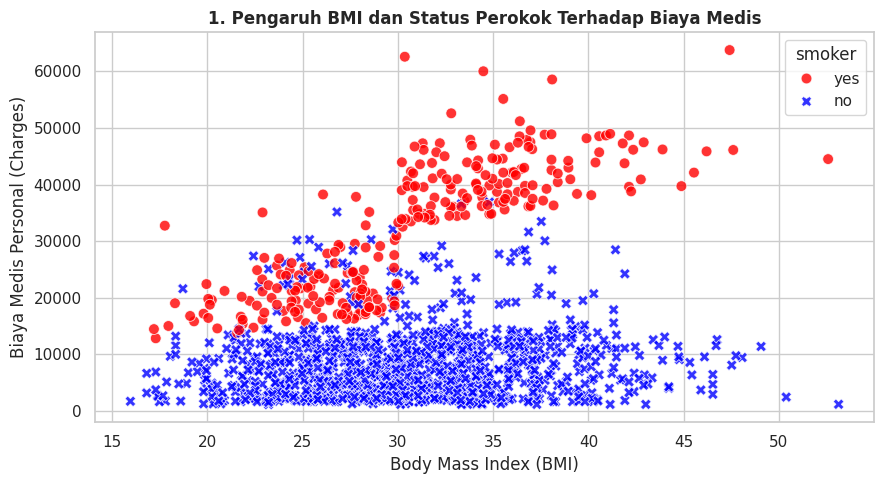

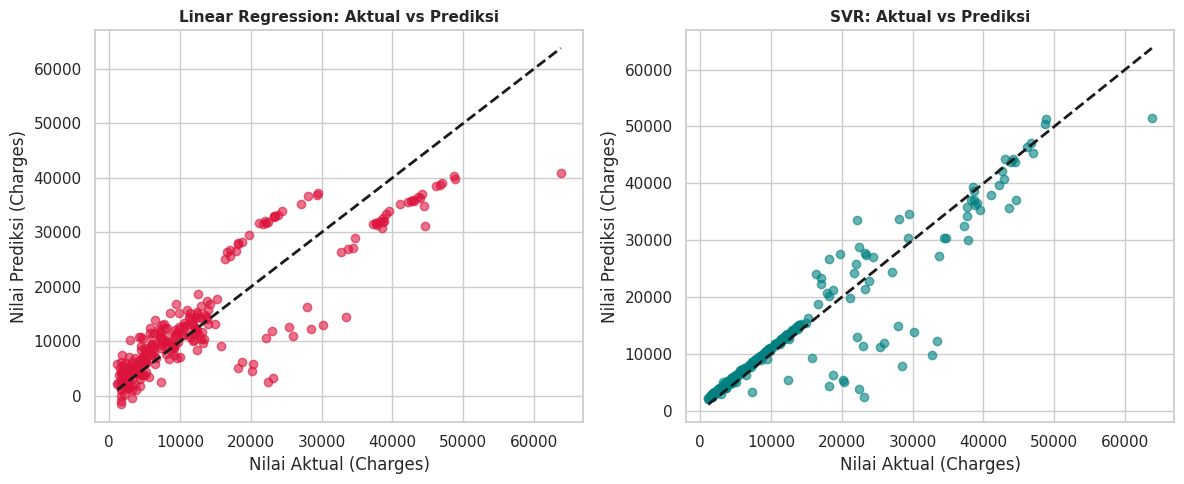

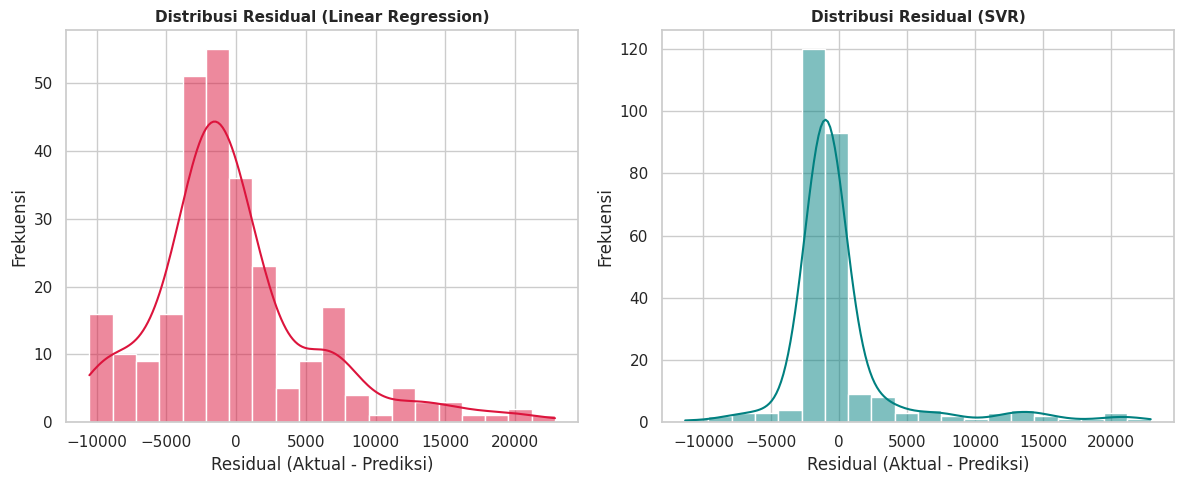

In [46]:
# Grafik 1: Scatter Plot - BMI vs Charges berdasarkan Status Perokok
plt.figure(figsize=(9, 5))
sns.scatterplot(
    x='bmi',
    y='charges',
    hue='smoker',
    style='smoker',
    data=df,
    palette={'yes': 'red', 'no': 'blue'},
    alpha=0.8,
    s=60,
)
plt.title(
    '1. Pengaruh BMI dan Status Perokok Terhadap Biaya Medis',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Biaya Medis Personal (Charges)')
plt.tight_layout()
plt.show()

# Grafik 2: Perbandingan Nilai Aktual vs Prediksi (Linear Regression vs SVR)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lr, alpha=0.6, color='crimson')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title(
    'Linear Regression: Aktual vs Prediksi', fontsize=11, fontweight='bold'
)
plt.xlabel('Nilai Aktual (Charges)')
plt.ylabel('Nilai Prediksi (Charges)')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_svr, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('SVR: Aktual vs Prediksi', fontsize=11, fontweight='bold')
plt.xlabel('Nilai Aktual (Charges)')
plt.ylabel('Nilai Prediksi (Charges)')

plt.tight_layout()
plt.show()

# Grafik 3: Distribusi Residual (Error Prediksi)
res_lr = y_test - y_pred_lr
res_svr = y_test - y_pred_svr

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(res_lr, kde=True, color='crimson', bins=20)
plt.title(
    'Distribusi Residual (Linear Regression)', fontsize=11, fontweight='bold'
)
plt.xlabel('Residual (Aktual - Prediksi)')
plt.ylabel('Frekuensi')

plt.subplot(1, 2, 2)
sns.histplot(res_svr, kde=True, color='teal', bins=20)
plt.title('Distribusi Residual (SVR)', fontsize=11, fontweight='bold')
plt.xlabel('Residual (Aktual - Prediksi)')
plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# **Analisis**
1. Pengaruh Variabel Non-Linier:
   - Scatter plot menunjukkan adanya pola non-linier yang sangat kuat antara
     status perokok ('smoker') dan 'bmi'. Bagi nasabah perokok dengan BMI > 30,
     biaya medis melonjak secara eksponensial.
   - Regresi Linier gagal menangkap pola ini secara sempurna karena sifat
     asumsinya yang linier lurus.
2. Performa SVR vs Regresi Linier:
   - SVR dengan Kernel RBF unggul jauh dengan R2 = 0.8690 (dibandingkan
     Linear Regression yang R2 = 0.7836).
   - Rata-rata kesalahan prediksi (MAE) berhasil ditekan dari $4,181.19
     menjadi $2,417.03 pada model SVR.
3. Pentingnya Feature Scaling:
   - Feature Scaling (StandardScaler) sangat penting pada SVR karena algoritma
     ini berbasis perhitungan jarak. Tanpa scaling pada X dan y, model SVR
     tidak dapat mencapai performa optimalnya.